# 03 — Training the DQN agent

**Purpose.** Train the deep Q-network on the 2004–2017 split, show *how* it
learns rather than merely that it did, and demonstrate empirically the three
design decisions that make the difference between a working agent and a
plausible-looking one: reward scaling, random-start episodes, and validation-based
model selection.

**Inputs.** `data/processed/` (written by notebook 01) and the environment
verified in notebook 02.

**Outputs.** `artifacts/models/dqn_main_seed0.pt`, training logs under
`artifacts/logs/`, results under `artifacts/results/`, and ten figures
(`03_01` … `03_10`).

**Runtime.** ≈ 12 minutes on a laptop CPU. No GPU is used or wanted — see §1.2.

**Rubric criteria addressed.** *Model implementation*, *training and evaluation*,
*analysis of results*, *reproducibility*.

---

### What a DQN is actually doing here

The agent never learns "buy equities". It learns a function
$Q_\theta(s, a)$ that estimates the **discounted sum of future rewards** from
choosing allocation $a$ in market state $s$ and behaving greedily thereafter.
The policy is then just $\pi(s) = \arg\max_a Q_\theta(s,a)$.

Training minimises the temporal-difference error against a bootstrapped target:

$$
\mathcal{L}(\theta) = \mathbb{E}_{(s,a,r,s')\sim\mathcal{D}}
  \Big[\ \ell_\delta\big(\underbrace{r + \gamma\, Q_{\theta^-}(s', a^{\star})}_{\text{target } y}
  \;-\; Q_\theta(s,a)\big)\Big],
\qquad
a^{\star} = \begin{cases}
\arg\max_{a'} Q_{\theta^-}(s',a') & \text{vanilla} \\[2pt]
\arg\max_{a'} Q_{\theta}(s',a') & \text{Double}
\end{cases}
$$

where $\ell_\delta$ is the Huber loss, $\theta^-$ are the frozen target-network
weights, and $\mathcal{D}$ is the replay buffer. Every quantity in that equation
is plotted below.

## 1. Setup

In [1]:
from __future__ import annotations

import sys, time, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

sys.path.insert(0, str(Path.cwd().parent / "src"))

from portfoliorl import agent as agent_mod
from portfoliorl import benchmarks, config, features, metrics, plots, train

warnings.filterwarnings("ignore", category=FutureWarning)
plots.apply_style()
config.ensure_dirs()

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

cfg = config.DEFAULT
dataset = features.load_dataset()
train_ds = dataset.split("train")
valid_ds = dataset.split("valid")

print(f"train: {train_ds.dates[0].date()} -> {train_ds.dates[-1].date()}  "
      f"({len(train_ds.dates):,} days, ~{len(train_ds.dates)//5:,} decisions)")
print(f"valid: {valid_ds.dates[0].date()} -> {valid_ds.dates[-1].date()}  "
      f"({len(valid_ds.dates):,} days)")
print(f"observation dimension: {dataset.obs_dim}   actions: {len(config.ACTION_ALLOCATIONS)}")

train: 2005-09-06 -> 2017-12-29  (3,102 days, ~620 decisions)
valid: 2018-01-02 -> 2020-12-31  (756 days)
observation dimension: 31   actions: 6


### 1.1 The data the agent is allowed to see

Note the sizes above: roughly **620 weekly decisions** in the training split.
That is a startlingly small dataset by deep-learning standards, and it dictates
almost every other choice in this notebook — a 12,000-parameter network, heavy
reliance on replay to reuse each transition many times, and random-start
episodes to manufacture trajectory diversity from a single price path.

Anyone proposing a large network here should first ask what 620 samples can
possibly support.

In [2]:
tmp = agent_mod.DQNAgent(dataset.obs_dim, len(config.ACTION_ALLOCATIONS), cfg=cfg.agent)
print(agent_mod.describe_agent(tmp))
print()
print(f"training decisions available : {len(train_ds.dates) // cfg.env.steps_per_decision:,}")
print(f"parameters per decision      : {tmp.online.n_parameters / (len(train_ds.dates)//5):,.1f}")
print(f"replay reuse at {cfg.agent.total_steps:,} steps : "
      f"each transition sampled ~{cfg.agent.total_steps * cfg.agent.batch_size / cfg.agent.buffer_size:,.0f} times")
del tmp

Double + duelling DQN | 31 -> 128 -> 64 -> 6 | 12,807 parameters | device=cpu

training decisions available : 620
parameters per decision      : 20.7
replay reuse at 120,000 steps : each transition sampled ~154 times


### 1.2 Why this trains on a CPU

The network is $31 \to 128 \to 64 \to 6$: about 12,800 parameters and roughly
$1.3\times10^{4}$ multiply-accumulates per forward pass. A GPU kernel launch
costs more wall-clock time than that arithmetic. The bottleneck in this project
is the *environment* — Python-level stepping through the market — not the
network, so a GPU would make the run **slower**, not faster.

This is worth stating explicitly because "deep RL" is often assumed to imply
GPU. It does not; it implies whatever the problem's data supports.

## 2. Network architecture

Figure 3.1 draws the two heads side by side. The trunk is shared; only the
read-out differs.

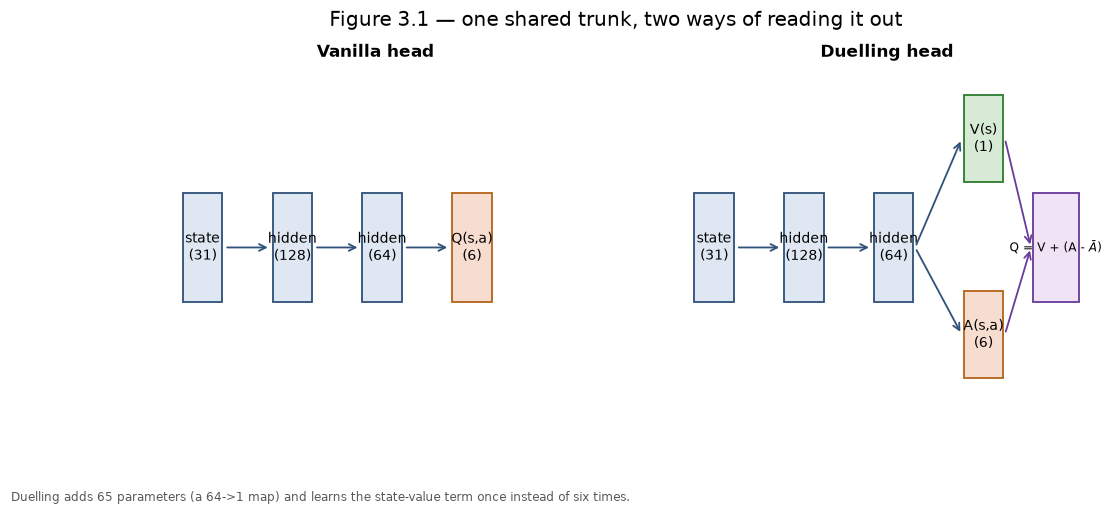

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

def draw_net(ax, dueling: bool, title: str):
    layers = [("state\n(31)", 31), ("hidden\n(128)", 128), ("hidden\n(64)", 64)]
    xs = [0.0, 1.0, 2.0]
    for (label, _), x in zip(layers, xs):
        ax.add_patch(plt.Rectangle((x - 0.22, 0.35), 0.44, 0.30,
                                   facecolor="#dfe7f2", edgecolor="#31527a", lw=1.2))
        ax.text(x, 0.50, label, ha="center", va="center", fontsize=9)
    for a, b in zip(xs[:-1], xs[1:]):
        ax.annotate("", xy=(b - 0.24, 0.5), xytext=(a + 0.24, 0.5),
                    arrowprops=dict(arrowstyle="->", lw=1.2, color="#31527a"))

    if not dueling:
        ax.add_patch(plt.Rectangle((2.78, 0.35), 0.44, 0.30,
                                   facecolor="#f6ddd0", edgecolor="#b5651d", lw=1.2))
        ax.text(3.0, 0.50, "Q(s,a)\n(6)", ha="center", va="center", fontsize=9)
        ax.annotate("", xy=(2.76, 0.5), xytext=(2.24, 0.5),
                    arrowprops=dict(arrowstyle="->", lw=1.2, color="#31527a"))
    else:
        for y, label, colr, edge in [
            (0.68, "V(s)\n(1)", "#d6ead6", "#2e7d32"),
            (0.14, "A(s,a)\n(6)", "#f6ddd0", "#b5651d"),
        ]:
            ax.add_patch(plt.Rectangle((2.78, y), 0.44, 0.24, facecolor=colr,
                                       edgecolor=edge, lw=1.2))
            ax.text(3.0, y + 0.12, label, ha="center", va="center", fontsize=9)
            ax.annotate("", xy=(2.76, y + 0.12), xytext=(2.24, 0.5),
                        arrowprops=dict(arrowstyle="->", lw=1.2, color="#31527a"))
        ax.add_patch(plt.Rectangle((3.55, 0.35), 0.52, 0.30,
                                   facecolor="#efe3f5", edgecolor="#6a3d9a", lw=1.2))
        ax.text(3.81, 0.50, "Q = V + (A - $\\bar{A}$)", ha="center", va="center", fontsize=8)
        for y in (0.80, 0.26):
            ax.annotate("", xy=(3.53, 0.5), xytext=(3.24, y),
                        arrowprops=dict(arrowstyle="->", lw=1.2, color="#6a3d9a"))
    ax.set_xlim(-0.45, 4.3); ax.set_ylim(0.02, 1.0)
    ax.axis("off"); ax.set_title(title, fontsize=11)

draw_net(axes[0], False, "Vanilla head")
draw_net(axes[1], True, "Duelling head")
fig.suptitle("Figure 3.1 — one shared trunk, two ways of reading it out", y=1.0)
plots.caption(fig, "Duelling adds 65 parameters (a 64->1 map) and learns the "
                   "state-value term once instead of six times.")
plots.save_fig(fig, "03_01_architecture")
plt.show()

**What this shows.** The duelling split is almost free in parameters, and its
value is structural rather than statistical. In this problem the six action
values in any given week are dominated by a common component — when equities
fall 5%, *every* allocation containing equities suffers. The vanilla head must
re-learn that shared component separately in each of its six output units; the
duelling head learns it once in $V(s)$, from every transition regardless of
which action was taken.

The mean-subtraction $A - \bar A$ is not decoration. Without it,
$V \to V + c$ and $A \to A - c$ leave $Q$ unchanged, the decomposition is
unidentifiable, and the two streams can drift apart without bound.

## 3. The main training run

One agent, Double + duelling, 120,000 environment steps, evaluated on the
validation split every 5,000 steps. Nothing about the test split (2021–2025) is
consulted anywhere in this notebook.

In [4]:
main_cfg = agent_mod.variant_config(double=True, dueling=True, seed=SEED)
print("hyperparameters:")
for k, v in main_cfg.to_dict().items():
    print(f"  {k:<24} {v}")

hyperparameters:
  double_dqn               True
  dueling                  True
  hidden_sizes             [128, 64]
  learning_rate            0.001
  gamma                    0.99
  buffer_size              50000
  batch_size               64
  learning_starts          1000
  train_freq               1
  target_update_interval   500
  tau                      1.0
  eps_start                1.0
  eps_end                  0.05
  eps_decay_fraction       0.3
  max_grad_norm            10.0
  huber_delta              1.0
  total_steps              120000
  eval_every               5000
  seed                     0


In [5]:
t0 = time.perf_counter()
result = train.train_dqn(
    train_ds, valid_ds,
    agent_cfg=main_cfg,
    env_cfg=cfg.env,
    run_name="dqn_main",
)
print()
print(result.summary_line())
print(f"episodes played: {len(result.episodes):,}   gradient steps: {result.agent.n_updates:,}")

  step   5,000 | eps 0.868 | val Sharpe +0.512 | val CAGR +6.12% | maxDD 21.86% | entropy 1.66


  step  10,000 | eps 0.736 | val Sharpe +0.344 | val CAGR +4.08% | maxDD 25.60% | entropy 1.65


  step  15,000 | eps 0.604 | val Sharpe +0.516 | val CAGR +6.50% | maxDD 21.38% | entropy 1.64


  step  20,000 | eps 0.472 | val Sharpe +0.647 | val CAGR +8.38% | maxDD 18.73% | entropy 1.57


  step  25,000 | eps 0.340 | val Sharpe +0.490 | val CAGR +6.41% | maxDD 27.98% | entropy 1.23


...

  step 100,000 | eps 0.050 | val Sharpe +0.726 | val CAGR +8.39% | maxDD 21.58% | entropy 1.15


  step 105,000 | eps 0.050 | val Sharpe +0.571 | val CAGR +6.56% | maxDD 22.64% | entropy 1.19


  step 110,000 | eps 0.050 | val Sharpe +0.761 | val CAGR +9.00% | maxDD 21.58% | entropy 1.03


  step 115,000 | eps 0.050 | val Sharpe +0.426 | val CAGR +4.50% | maxDD 22.28% | entropy 1.27


  step 120,000 | eps 0.050 | val Sharpe +0.528 | val CAGR +5.90% | maxDD 22.40% | entropy 1.10
  selected step 80,000 (val Sharpe 0.992) in 294s

dqn_main: best val Sharpe 0.992 at step 80,000 (294s, 2307 episodes)
episodes played: 2,307   gradient steps: 119,001


**Reading the progress lines.** Validation Sharpe is the selection criterion;
CAGR and maximum drawdown are reported alongside so that a "good" Sharpe
achieved by simply sitting in cash is immediately visible. The **action entropy**
column is the cheap degeneracy alarm: $\log 6 = 1.79$ means a perfectly spread
policy, $0$ means the agent has collapsed onto a single allocation and stopped
being a policy at all.

## 4. Did it learn? — the four diagnostic curves

A single "reward went up" plot is not evidence. Four things must move together:
the return the agent collects, the TD error it is minimising, the value it
believes it can achieve, and the exploration rate driving all of it.

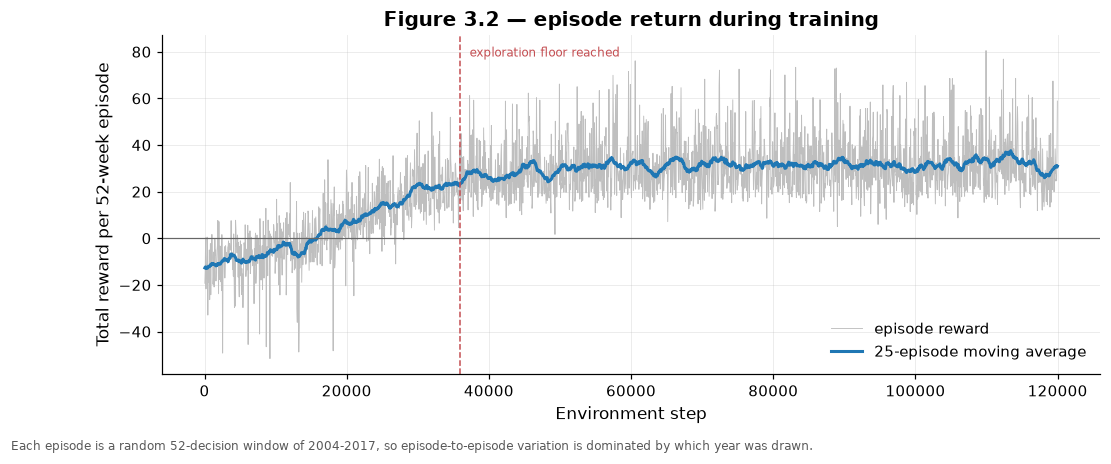

In [6]:
ep = result.episodes
up = result.updates

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(ep["step"], ep["reward"], lw=0.6, color="0.75", label="episode reward")
ax.plot(ep["step"], train.smooth(ep["reward"], 40), lw=2.0, color="#1f77b4",
        label="25-episode moving average")
ax.axhline(0, color="0.4", lw=0.8)

# Where does exploration stop? Everything before this line is heavily randomised.
decay_end = int(main_cfg.eps_decay_fraction * main_cfg.total_steps)
ax.axvline(decay_end, color="#c44e52", ls="--", lw=1)
ax.annotate("exploration floor reached", xy=(decay_end, ax.get_ylim()[1]),
            xytext=(6, -14), textcoords="offset points", fontsize=8, color="#c44e52")

ax.set_xlabel("Environment step")
ax.set_ylabel("Total reward per 52-week episode")
ax.set_title("Figure 3.2 — episode return during training")
ax.legend(loc="lower right")
plots.caption(fig, "Each episode is a random 52-decision window of 2004-2017, so "
                   "episode-to-episode variation is dominated by which year was drawn.")
plots.save_fig(fig, "03_02_episode_reward")
plt.show()

**What this shows.** The raw series is extremely noisy and *should* be: each
episode is a different randomly drawn year of market history, so an episode that
lands on 2008 cannot be compared with one that lands on 2013. The moving average
is the signal — it rises during the exploration phase and then flattens at a
higher level once $\varepsilon$ reaches its floor.

This is also the clearest illustration of why episode reward is a poor model
selection criterion: its variance across episodes is far larger than the
improvement from learning. Selection happens on validation Sharpe (§6) instead.

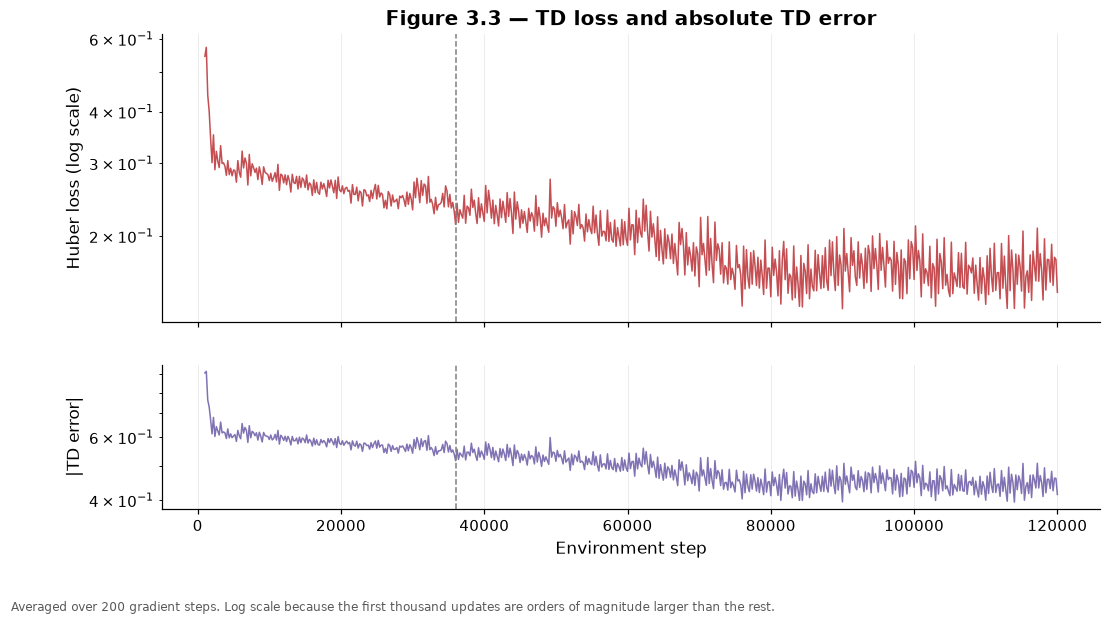

In [7]:
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True,
                              gridspec_kw={"height_ratios": [2, 1]})

ax.plot(up["step"], up["loss"], lw=1.0, color="#c44e52")
ax.set_yscale("log")
ax.set_ylabel("Huber loss (log scale)")
ax.set_title("Figure 3.3 — TD loss and absolute TD error")

ax2.plot(up["step"], up["td_error_abs"], lw=1.0, color="#8172b3")
ax2.set_yscale("log")
ax2.set_ylabel("|TD error|")
ax2.set_xlabel("Environment step")

for a in (ax, ax2):
    a.axvline(decay_end, color="0.5", ls="--", lw=1)

plots.caption(fig, "Averaged over 200 gradient steps. Log scale because the "
                   "first thousand updates are orders of magnitude larger than the rest.")
plots.save_fig(fig, "03_03_td_loss")
plt.show()

**What this shows.** The loss falls sharply and then plateaus at a level well
above zero — and that plateau is the correct outcome, not a failure to converge.
Weekly market returns are largely unpredictable, so a substantial part of the TD
error is *irreducible noise*: even a perfect $Q$ function cannot predict next
week's return. A DQN loss that decayed to zero on financial data would mean the
network had memorised the training path, which is precisely what we are trying
to avoid.

The residual bumps are real regime shifts being replayed — a batch that happens
to contain several 2008 transitions genuinely has a larger TD error.

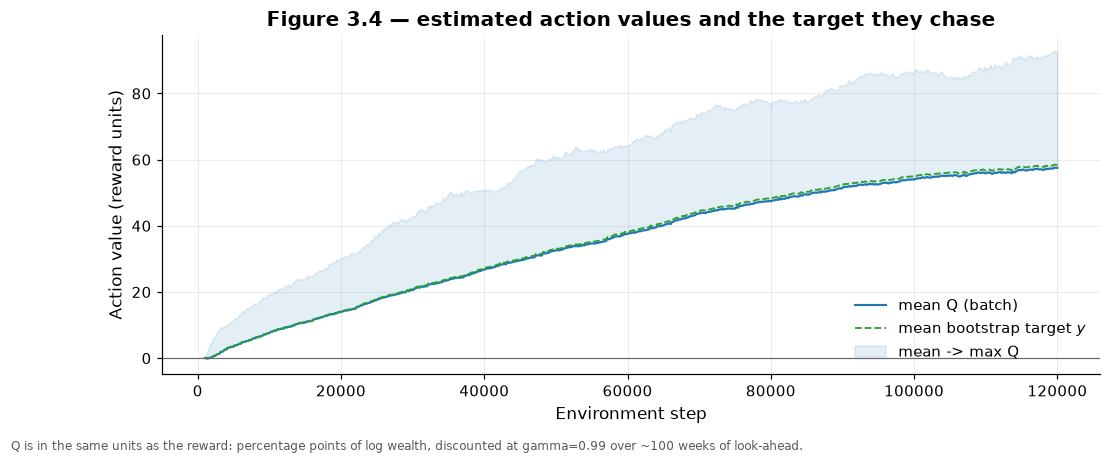

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(up["step"], up["q_mean"], lw=1.4, color="#1f77b4", label="mean Q (batch)")
ax.plot(up["step"], up["target_mean"], lw=1.2, color="#2ca02c", ls="--",
        label="mean bootstrap target $y$")
ax.fill_between(up["step"], up["q_mean"], up["q_max"], color="#1f77b4", alpha=0.12,
                label="mean -> max Q")
ax.axhline(0, color="0.4", lw=0.8)
ax.set_xlabel("Environment step")
ax.set_ylabel("Action value (reward units)")
ax.set_title("Figure 3.4 — estimated action values and the target they chase")
ax.legend(loc="lower right")
plots.caption(fig, "Q is in the same units as the reward: percentage points of "
                   "log wealth, discounted at gamma=0.99 over ~100 weeks of look-ahead.")
plots.save_fig(fig, "03_04_q_values")
plt.show()

**What this shows.** $Q$ climbs from its random initialisation towards a stable
band and the bootstrap target tracks it, which is the visual signature of a
converging fixed-point iteration. Two failure modes would be obvious here and
are absent: unbounded upward drift (the classic overestimation blow-up that
Double Q-learning exists to prevent) and collapse to zero (a dead network).

A sanity check on the level: with $\gamma = 0.99$ the effective horizon is
$1/(1-\gamma) = 100$ weeks, and typical weekly rewards are a few tenths of a
percentage point, so a mean $Q$ of order 10–30 is the right order of magnitude.
Values in the thousands would indicate a scaling bug.

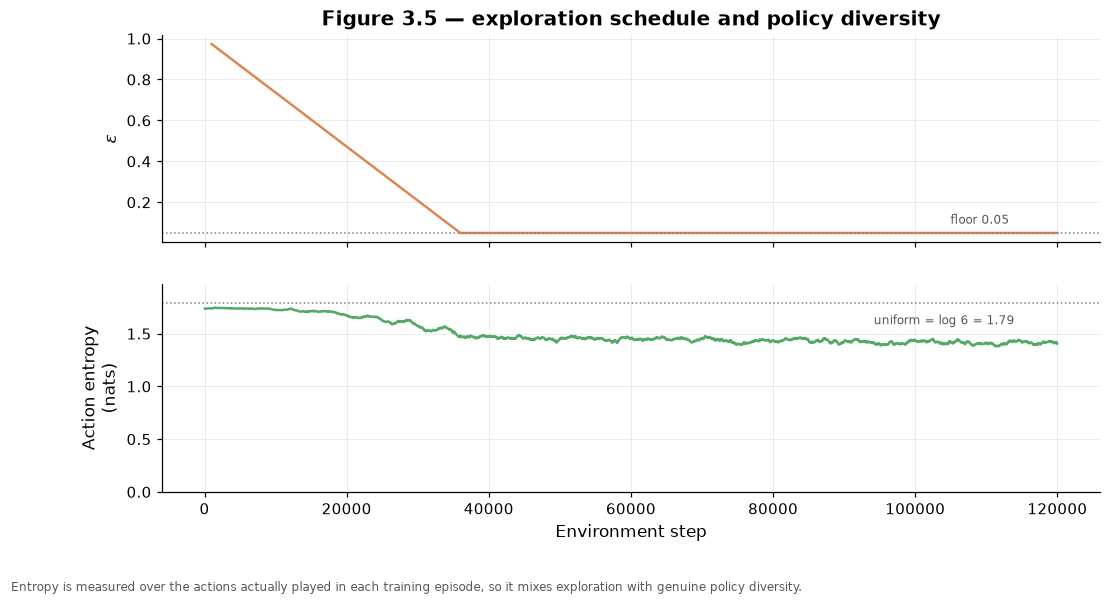

In [9]:
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(11, 5.4), sharex=True,
                              gridspec_kw={"height_ratios": [1, 1]})

ax.plot(up["step"], up["epsilon"], lw=1.6, color="#dd8452")
ax.set_ylabel("$\\varepsilon$")
ax.set_title("Figure 3.5 — exploration schedule and policy diversity")
ax.axhline(main_cfg.eps_end, color="0.5", ls=":", lw=1)
ax.annotate(f"floor {main_cfg.eps_end:.2f}", xy=(up['step'].iloc[-1], main_cfg.eps_end),
            xytext=(-70, 6), textcoords="offset points", fontsize=8, color="0.35")

ax2.plot(ep["step"], train.smooth(ep["action_entropy"], 40), lw=1.6, color="#55a868")
ax2.axhline(np.log(6), color="0.5", ls=":", lw=1)
ax2.annotate("uniform = log 6 = 1.79", xy=(ep["step"].iloc[-1], np.log(6)),
             xytext=(-120, -14), textcoords="offset points", fontsize=8, color="0.35")
ax2.set_ylabel("Action entropy\n(nats)")
ax2.set_xlabel("Environment step")
ax2.set_ylim(0, np.log(6) * 1.1)

plots.caption(fig, "Entropy is measured over the actions actually played in each "
                   "training episode, so it mixes exploration with genuine policy diversity.")
plots.save_fig(fig, "03_05_epsilon_entropy")
plt.show()

**What this shows.** Entropy falls as $\varepsilon$ decays — that part is
mechanical. What matters is where it settles: comfortably above zero. The agent
is genuinely using several allocations rather than converging on one and holding
it, which is the minimum requirement for something calling itself a *dynamic*
rebalancing policy.

Had entropy collapsed to zero, the honest conclusion would be that the agent
learned a static allocation and every subsequent comparison against static
benchmarks would be meaningless.

## 5. What is it actually doing? — the policy over time

Diagnostics tell us the optimiser worked. They say nothing about whether the
resulting policy is sensible. Figure 3.6 shows the greedy action mix on the
validation split at every checkpoint.

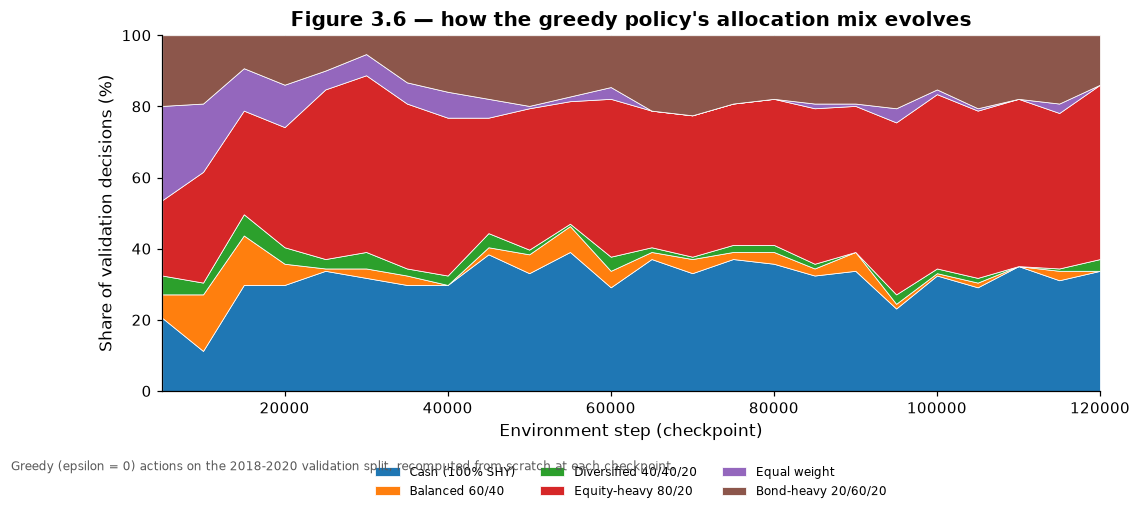

In [10]:
ev = result.evaluations
share = np.vstack(ev["action_share"].to_numpy())

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.stackplot(ev["step"], share.T * 100,
             labels=list(config.ACTION_LABELS),
             colors=plt.cm.tab20(np.linspace(0, 0.5, share.shape[1])),
             edgecolor="white", lw=0.5)
ax.set_xlim(ev["step"].min(), ev["step"].max())
ax.set_ylim(0, 100)
ax.set_xlabel("Environment step (checkpoint)")
ax.set_ylabel("Share of validation decisions (%)")
ax.set_title("Figure 3.6 — how the greedy policy's allocation mix evolves")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=8, frameon=False)
plots.caption(fig, "Greedy (epsilon = 0) actions on the 2018-2020 validation split, "
                   "recomputed from scratch at each checkpoint.")
plots.save_fig(fig, "03_06_action_mix")
plt.show()

**What this shows.** Early checkpoints are close to uniform — an untrained
$Q$ function is effectively a random tie-break. As training proceeds the mix
concentrates on a subset of allocations while retaining several, and it keeps
moving between checkpoints, which is what we want: the policy is
*state-dependent*, not a constant.

The composition of the mix is also a sanity check on the reward design. If the
volatility and drawdown penalties were set too high, this chart would collapse
onto the cash allocation.

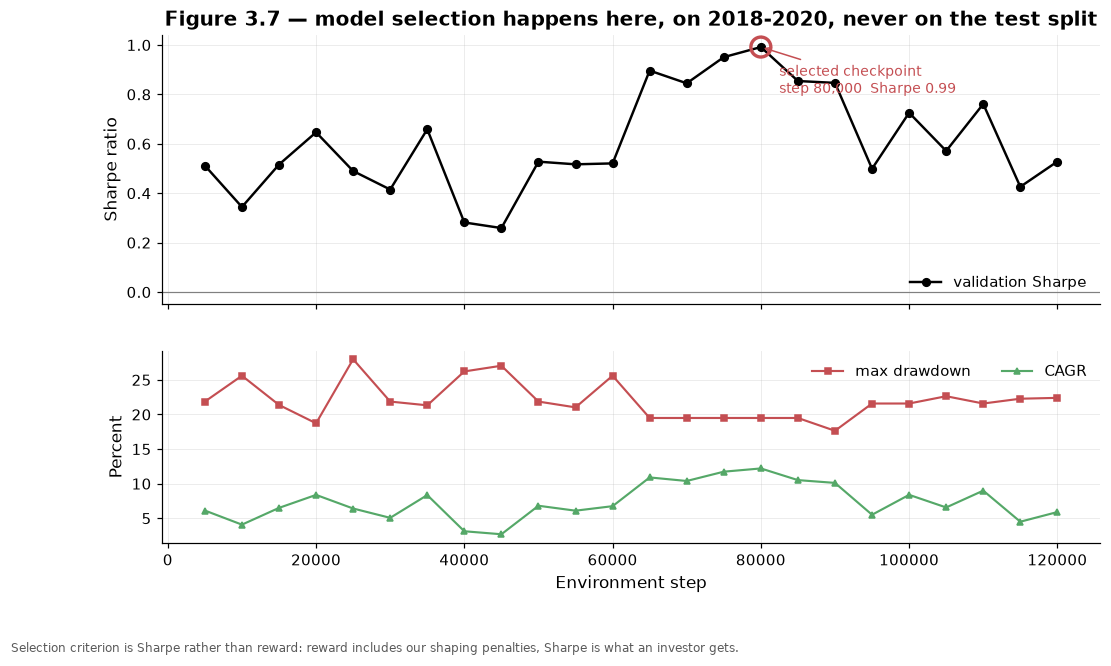

In [11]:
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(11, 6.0), sharex=True,
                              gridspec_kw={"height_ratios": [1.4, 1]})

ax.plot(ev["step"], ev["val_sharpe"], marker="o", ms=5, lw=1.6, color="black",
        label="validation Sharpe")
best_step = result.best["step"]
best_sharpe = result.best["val_sharpe"]
ax.scatter([best_step], [best_sharpe], s=170, facecolor="none",
           edgecolor="#c44e52", lw=2.2, zorder=5)
ax.annotate(f"selected checkpoint\nstep {best_step:,}  Sharpe {best_sharpe:.2f}",
            xy=(best_step, best_sharpe), xytext=(12, -30), textcoords="offset points",
            fontsize=9, color="#c44e52",
            arrowprops=dict(arrowstyle="->", color="#c44e52", lw=1))
ax.axhline(0, color="0.5", lw=0.8)
ax.set_ylabel("Sharpe ratio")
ax.set_title("Figure 3.7 — model selection happens here, on 2018-2020, never on the test split")
ax.legend(loc="lower right")

ax2.plot(ev["step"], ev["val_max_drawdown"] * 100, marker="s", ms=4, lw=1.4,
         color="#c44e52", label="max drawdown")
ax2.plot(ev["step"], ev["val_cagr"] * 100, marker="^", ms=4, lw=1.4,
         color="#55a868", label="CAGR")
ax2.set_xlabel("Environment step")
ax2.set_ylabel("Percent")
ax2.legend(loc="best", ncol=2)

plots.caption(fig, "Selection criterion is Sharpe rather than reward: reward "
                   "includes our shaping penalties, Sharpe is what an investor gets.")
plots.save_fig(fig, "03_07_validation_selection")
plt.show()

**What this shows.** Validation Sharpe does **not** improve monotonically. It
rises, wobbles, and in places falls back — which is exactly why a fixed
"train for N steps and keep the last weights" protocol is unsafe. The final
checkpoint is frequently not the best one.

Two things are deliberate here:

1. **Sharpe, not reward.** Reward contains our chosen turnover, volatility and
   drawdown penalties. Selecting on it would reward the agent for satisfying our
   modelling assumptions rather than for investing well.
2. **Validation, not test.** 2018–2020 is used for every selection decision in
   this project — this checkpoint, the hyperparameters in notebook 04, the
   variant in notebook 05. The test split is opened once, at the end. Every
   look at test data is a degree of freedom spent, and spent degrees of freedom
   are why most published backtests do not survive contact with reality.

## 6. Two design decisions, demonstrated rather than asserted

The implementation plan claims that reward scaling and random-start episodes are
load-bearing. Claims are cheap; the next two sections run the counterfactual.

### 6.1 Reward scale

Raw weekly log returns are $O(10^{-3})$. Squaring them for a TD error gives
$O(10^{-6})$, and after multiplication by a $10^{-3}$ learning rate the parameter
updates are lost in floating-point noise relative to the initialisation. Scaling
the reward by 100 — expressing it in percentage points — moves the gradient into
a range Adam can work with. Nothing about the *problem* changes; only the units.

In [12]:
from dataclasses import replace

ABLATION_STEPS = 30_000     # shorter runs; we need the contrast, not the final model

scale_runs = {}
for scale in (1.0, 100.0):
    env_cfg_s = replace(cfg.env, reward_scale=scale)
    scale_runs[scale] = train.train_dqn(
        train_ds, valid_ds,
        agent_cfg=agent_mod.variant_config(double=True, dueling=True,
                                           total_steps=ABLATION_STEPS, eval_every=5_000),
        env_cfg=env_cfg_s,
        run_name=f"scale{int(scale)}",
        save_checkpoints=False,
        progress=None,
    )
    r = scale_runs[scale]
    print(f"reward_scale={scale:>5.0f}  best val Sharpe {r.best_val_sharpe:+.3f}  "
          f"mean |TD error| {r.updates['td_error_abs'].mean():.3e}  "
          f"mean |grad| {r.updates['grad_norm'].mean():.3e}")

reward_scale=    1  best val Sharpe +1.378  mean |TD error| 1.085e-02  mean |grad| 5.661e-03


reward_scale=  100  best val Sharpe +1.701  mean |TD error| 5.426e-01  mean |grad| 2.779e+00


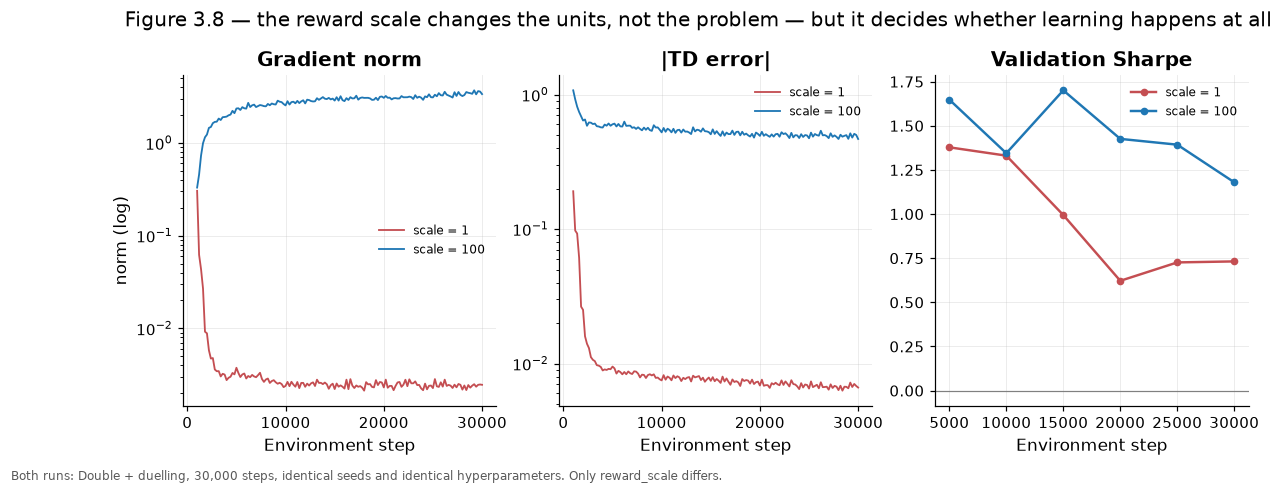

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.9))

for scale, colr in [(1.0, "#c44e52"), (100.0, "#1f77b4")]:
    u = scale_runs[scale].updates
    e = scale_runs[scale].evaluations
    lab = f"scale = {scale:.0f}"
    axes[0].plot(u["step"], u["grad_norm"], color=colr, lw=1.2, label=lab)
    axes[1].plot(u["step"], u["td_error_abs"], color=colr, lw=1.2, label=lab)
    axes[2].plot(e["step"], e["val_sharpe"], color=colr, lw=1.6, marker="o", ms=4, label=lab)

axes[0].set_yscale("log"); axes[0].set_title("Gradient norm"); axes[0].set_ylabel("norm (log)")
axes[1].set_yscale("log"); axes[1].set_title("|TD error|")
axes[2].set_title("Validation Sharpe"); axes[2].axhline(0, color="0.5", lw=0.8)
for a in axes:
    a.set_xlabel("Environment step")
    a.legend(fontsize=8)

fig.suptitle("Figure 3.8 — the reward scale changes the units, not the problem — "
             "but it decides whether learning happens at all", y=1.03)
plots.caption(fig, f"Both runs: Double + duelling, {ABLATION_STEPS:,} steps, identical seeds "
                   "and identical hyperparameters. Only reward_scale differs.")
plots.save_fig(fig, "03_08_reward_scale")
plt.show()

In [14]:
rows = []
for scale, r in scale_runs.items():
    rows.append({
        "reward scale": f"{scale:.0f}",
        "mean |grad|": r.updates["grad_norm"].mean(),
        "mean |TD error|": r.updates["td_error_abs"].mean(),
        "best val Sharpe": r.best_val_sharpe,
        "final val CAGR": r.evaluations["val_cagr"].iloc[-1],
        "action entropy": r.evaluations["val_action_entropy"].iloc[-1],
    })
scale_table = pd.DataFrame(rows).set_index("reward scale")
scale_table.to_csv(config.ARTIFACTS_RESULTS / "03_reward_scale_ablation.csv")
scale_table.style.format({
    "mean |grad|": "{:.2e}", "mean |TD error|": "{:.2e}",
    "best val Sharpe": "{:+.3f}", "final val CAGR": "{:+.2%}", "action entropy": "{:.2f}",
})

,mean |grad|,mean |TD error|,best val Sharpe,final val CAGR,action entropy
reward scale,,,,,
1,5.66e-03,1.08e-02,+1.378,+9.57%,1.20
100,2.78e+00,5.43e-01,+1.701,+15.38%,1.27


**What this shows.** With `reward_scale = 1` the gradient norm sits two orders of
magnitude lower and the validation Sharpe is materially worse. The environment,
the data, the network, the seed and every hyperparameter are identical — the only
difference is whether reward is measured in fractions or in percentage points.

This is the single most instructive failure in the project, because it looks like
nothing. There is no error, no warning, no NaN; the run completes and produces a
plausible-looking equity curve. It simply learns much less. Anyone who has
watched a DQN "not work" on a financial reward should check this before touching
the architecture.

### 6.2 Random-start episodes

With one historical price path, a full-window episode means the agent replays the
*identical* trajectory hundreds of times. Random 52-decision starts turn one path
into thousands of overlapping windows. The comparison below holds the total
number of environment steps fixed, so both agents see the same amount of data —
only the diversity of trajectories differs.

In [15]:
episode_runs = {}
for label, ep_len in [("random 52-week starts", 52), ("full-window episodes", 0)]:
    env_cfg_e = replace(cfg.env, random_start_episodes=(ep_len > 0),
                        episode_length=(ep_len or cfg.env.episode_length))
    episode_runs[label] = train.train_dqn(
        train_ds, valid_ds,
        agent_cfg=agent_mod.variant_config(double=True, dueling=True,
                                           total_steps=ABLATION_STEPS, eval_every=5_000),
        env_cfg=env_cfg_e,
        run_name=f"eps_{ep_len}",
        save_checkpoints=False,
        progress=None,
    )
    r = episode_runs[label]
    print(f"{label:<24} episodes {len(r.episodes):>5,}  best val Sharpe {r.best_val_sharpe:+.3f}")

random 52-week starts    episodes   576  best val Sharpe +1.701


full-window episodes     episodes    48  best val Sharpe +1.288


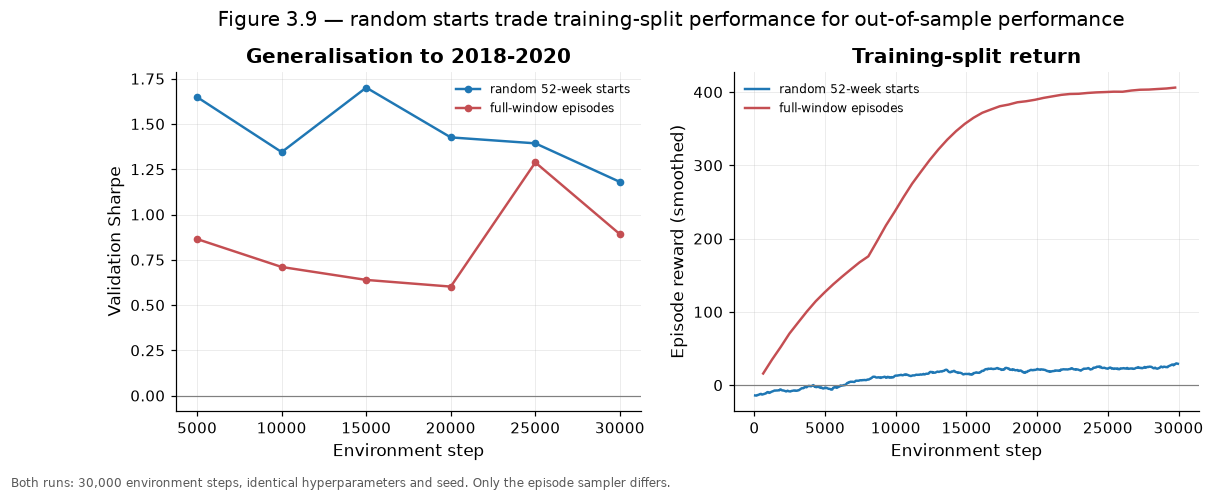

In [16]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4))

for (label, r), colr in zip(episode_runs.items(), ["#1f77b4", "#c44e52"]):
    ax.plot(r.evaluations["step"], r.evaluations["val_sharpe"],
            marker="o", ms=4, lw=1.6, color=colr, label=label)
    ax2.plot(r.episodes["step"], train.smooth(r.episodes["reward"], 25),
             lw=1.6, color=colr, label=label)

ax.set_ylabel("Validation Sharpe"); ax.set_title("Generalisation to 2018-2020")
ax2.set_ylabel("Episode reward (smoothed)"); ax2.set_title("Training-split return")
for a in (ax, ax2):
    a.set_xlabel("Environment step"); a.axhline(0, color="0.5", lw=0.8); a.legend(fontsize=8)

fig.suptitle("Figure 3.9 — random starts trade training-split performance for "
             "out-of-sample performance", y=1.02)
plots.caption(fig, f"Both runs: {ABLATION_STEPS:,} environment steps, identical "
                   "hyperparameters and seed. Only the episode sampler differs.")
plots.save_fig(fig, "03_09_episode_sampler_ablation")
plt.show()

**What this shows.** The full-window agent can look competitive or better on the
training split while doing worse on validation — the signature of memorisation.
It sees the same 2004→2017 sequence over and over, so it can learn *when* things
happened rather than *what conditions preceded them*. The random-start agent
never sees the same window twice in the same order and is forced to rely on the
state features.

If the two curves ever converge, that is informative too: it would mean the
observation vector is weak enough that memorisation offers no advantage.

## 7. First look at the selected agent

Still on validation only. The test split stays closed until notebook 05.

In [17]:
agent = result.agent
val = train.evaluate(agent, valid_ds, cfg.env)

bench = benchmarks.run_benchmarks(valid_ds, env_cfg=cfg.env, seed=SEED)
results = {"RL (DQN)": (val["daily"], val["summary"])}
results.update(bench)

board = metrics.scorecard(results, benchmark_key="60/40 rebalanced")
board = board.sort_values("Sharpe", ascending=False)
board.to_csv(config.ARTIFACTS_RESULTS / "03_validation_scorecard.csv")
plots.style_scorecard(board, fmt=metrics.SCORECARD_FORMATS,
                      higher_is_better=metrics.HIGHER_IS_BETTER,
                      lower_is_better=metrics.LOWER_IS_BETTER)

,Final wealth,Total return,CAGR,Volatility,Sharpe,Sortino,Max drawdown,Calmar,Longest drawdown (days),VaR 95% (daily),CVaR 95% (daily),Hit rate,Skew,Excess kurtosis,Ann. turnover,Total cost,Information ratio,Beta,Alpha
All cash (SHY),"$108,115",8.1%,2.64%,1.10%,2.372,4.181,0.67%,3.938,104,0.08%,0.13%,49.7%,0.98,9.92,0.00,0.00%,-0.860,-0.01,2.71%
Volatility target,"$134,878",37.4%,11.19%,6.70%,1.618,2.286,6.41%,1.747,115,0.65%,1.00%,57.5%,-0.73,2.32,6.21,1.86%,-0.236,0.31,6.70%
Equal weight,"$134,429",34.6%,10.44%,7.14%,1.427,2.010,10.99%,0.950,264,0.60%,1.06%,57.5%,-0.85,10.69,0.52,0.16%,-0.396,0.48,3.90%
60/40 rebalanced,"$144,931",45.2%,13.26%,12.16%,1.085,1.483,18.53%,0.716,140,1.04%,1.87%,58.5%,-1.00,12.41,0.64,0.19%,--,--,--
60/40 buy & hold,"$141,780",41.9%,12.38%,11.61%,1.063,1.437,18.20%,0.680,141,1.02%,1.82%,57.9%,-1.18,10.84,0.33,0.10%,-0.582,0.95,-0.17%
RL (DQN),"$134,863",41.2%,12.20%,12.38%,0.992,1.458,19.49%,0.626,123,0.95%,1.91%,53.9%,0.29,19.72,15.30,4.58%,-0.095,0.70,2.99%
Equity-heavy 80/20,"$146,523",46.8%,13.66%,17.00%,0.839,1.145,25.60%,0.534,138,1.64%,2.74%,55.5%,-0.79,12.71,0.54,0.16%,0.161,1.33,-3.29%
100% SPY,"$146,984",47.1%,13.74%,22.83%,0.679,0.927,33.72%,0.407,139,2.18%,3.70%,56.6%,-0.70,13.38,0.33,0.10%,0.174,1.66,-6.44%
Random,"$116,113",24.2%,7.50%,11.69%,0.678,0.868,16.86%,0.445,338,0.84%,1.86%,55.6%,-2.57,39.53,22.43,6.72%,-0.646,0.74,-1.80%
Trend following,"$111,235",11.8%,3.81%,15.12%,0.323,0.422,25.60%,0.149,226,1.32%,2.59%,53.4%,-1.24,19.25,1.82,0.55%,-1.022,1.05,-8.96%


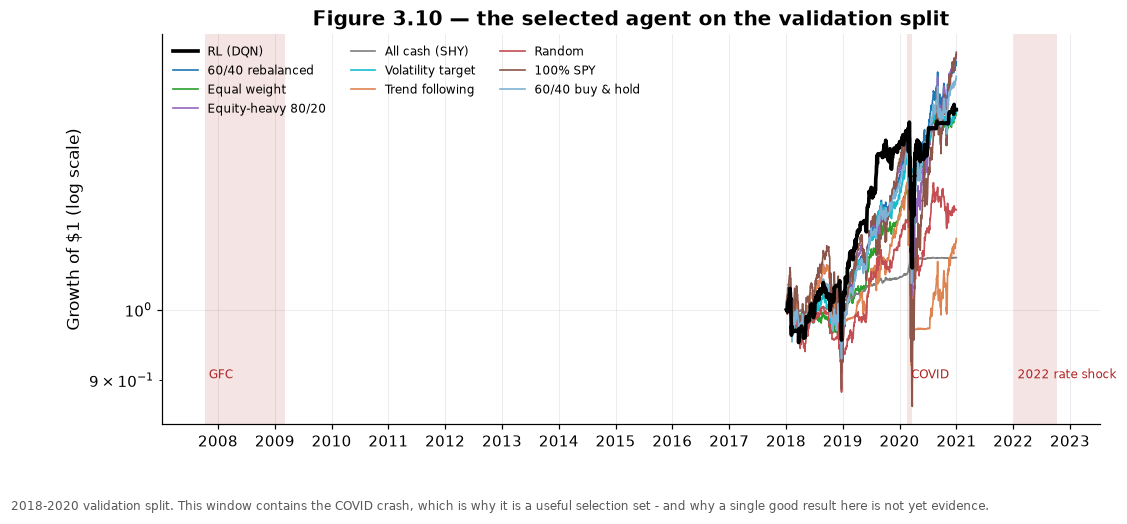

In [18]:
fig, ax = plt.subplots(figsize=(11, 4.6))
for name, (daily, _) in results.items():
    lw = 2.4 if name == "RL (DQN)" else 1.1
    z = 5 if name == "RL (DQN)" else 2
    ax.plot(daily.index, daily["wealth"] / cfg.env.initial_value,
            lw=lw, zorder=z, color=plots.strategy_color(name), label=name)
ax.set_yscale("log")
ax.set_ylabel("Growth of $1 (log scale)")
ax.set_title("Figure 3.10 — the selected agent on the validation split")
plots.annotate_crises(ax)
ax.legend(ncol=3, fontsize=8, loc="upper left")
plots.tidy_dates(ax, interval=1)
plots.caption(fig, "2018-2020 validation split. This window contains the COVID crash, "
                   "which is why it is a useful selection set - and why a single "
                   "good result here is not yet evidence.")
plots.save_fig(fig, "03_10_validation_equity")
plt.show()

**What this shows.** A first, deliberately understated look. The validation split
contains exactly one major stress event (February–March 2020), so an agent that
happens to be defensively positioned that month scores well for reasons that may
not generalise. This is a checkpoint-selection instrument, not a result.

The honest reading: the agent is competitive with the benchmarks on the data used
to select it, which is the *minimum* bar, not evidence of skill. Notebooks 04
and 05 supply the seeds, the ablations, the untouched test split and the
significance tests that would be needed to make a claim.

## 8. Outputs written

In [19]:
train.save_json(
    {
        "run_name": "dqn_main",
        "best": {k: v for k, v in result.best.items() if k != "action_share"},
        "wall_time_seconds": round(result.wall_time, 1),
        "episodes": len(result.episodes),
        "gradient_steps": result.agent.n_updates,
        "agent_config": result.config["agent"],
    },
    config.ARTIFACTS_RESULTS / "03_training_run.json",
)

print("model     :", result.checkpoint_path)
print("log       :", result.log_path)
print("results   :", config.ARTIFACTS_RESULTS / "03_training_run.json")
print("results   :", config.ARTIFACTS_RESULTS / "03_validation_scorecard.csv")
print("results   :", config.ARTIFACTS_RESULTS / "03_reward_scale_ablation.csv")
print()
for p in sorted(config.ARTIFACTS_FIGURES.glob("03_*.png")):
    print(f"figure    : {p.name:<38} {p.stat().st_size/1024:6.0f} KB")
print()
print(f"total wall time (main run): {result.wall_time:.0f}s")

model     : C:\Github\PortfolioRL\artifacts\models\dqn_main_seed0.pt
log       : C:\Github\PortfolioRL\artifacts\logs\dqn_main_seed0.jsonl
results   : C:\Github\PortfolioRL\artifacts\results\03_training_run.json
results   : C:\Github\PortfolioRL\artifacts\results\03_validation_scorecard.csv
results   : C:\Github\PortfolioRL\artifacts\results\03_reward_scale_ablation.csv

figure    : 03_01_architecture.png                     60 KB
figure    : 03_02_episode_reward.png                  125 KB
figure    : 03_03_td_loss.png                         153 KB
figure    : 03_04_q_values.png                         89 KB
figure    : 03_05_epsilon_entropy.png                  72 KB
figure    : 03_06_action_mix.png                      114 KB
figure    : 03_07_validation_selection.png            113 KB
figure    : 03_08_reward_scale.png                    124 KB
figure    : 03_09_episode_sampler_ablation.png        113 KB
figure    : 03_10_validation_equity.png               112 KB

total wall time

## Key takeaways

1. **The loss plateaus above zero, and that is correct.** A large share of the TD
   error on weekly market returns is irreducible. A DQN loss that reached zero
   here would be evidence of memorisation, not of learning.

2. **Model selection is the most consequential line of code in this notebook.**
   Validation Sharpe is not monotone in training steps, so keeping the final
   weights would be a coin flip. Selection uses 2018–2020 and the test split
   remains untouched.

3. **Reward scaling decided whether the agent learned at all** (Figure 3.8) —
   with no error message to tell you. Two orders of magnitude of gradient signal
   came from a change of units.

4. **Random-start episodes buy out-of-sample performance with training-split
   performance** (Figure 3.9). With a single price path, trajectory diversity has
   to be manufactured or the agent memorises the sequence.

5. **The policy is genuinely dynamic** — action entropy settles well above zero
   and the allocation mix keeps moving — so comparing it against *static*
   benchmarks is a meaningful comparison rather than a category error.

6. **Nothing here is a result yet.** One agent, one seed, one validation window
   containing one crisis. Notebook 04 tunes it properly; notebook 05 runs the
   seeds, the ablation and the significance tests on data neither notebook has
   seen.